In [ ]:
# Step 1 — Load Data
import pandas as pd
from src.config import PROCESSED_DATA_DIR, FIGURES_DIR, RESULTS_DIR, MODELS_DIR

df = pd.read_csv(
    PROCESSED_DATA_DIR / "feature_engineered_dataset.csv"
)

print(df.shape)

(100000, 22)


In [2]:
# Step 2 — Select Features

features = [
    'cpu_utilization',
    'memory_usage',
    'disk_io',
    'network_latency',
    'process_count',
    'thread_count',
    'context_switches',
    'cache_miss_rate',
    'temperature',
    'power_consumption',
    'uptime',
    'resource_stress_index',
    'cpu_memory_ratio',
    'disk_pressure',
    'context_switch_density',
    'cache_efficiency',
    'thermal_stress'
]

X = df[features]

y = df["status"]

In [3]:
# Step 3 — Standardize

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [4]:
# Model 1 — Z-Score

import numpy as np
from scipy.stats import zscore

z_scores = np.abs(
    zscore(X_scaled)
)

threshold = 3

z_predictions = (
    (z_scores > threshold)
    .any(axis=1)
).astype(int)

In [5]:
# Evaluate Z-Score

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

print(
    "Precision:",
    precision_score(y, z_predictions)
)

print(
    "Recall:",
    recall_score(y, z_predictions)
)

print(
    "F1:",
    f1_score(y, z_predictions)
)

Precision: 0.0026425066062665155
Recall: 0.013861386138613862
F1: 0.004438807863031071


In [6]:
# Model 2 — Robust Z-Score

from scipy.stats import median_abs_deviation

median = np.median(
    X_scaled,
    axis=0
)

mad = median_abs_deviation(
    X_scaled,
    axis=0
)

robust_z = (
    0.6745 *
    (X_scaled - median)
    /
    mad
)

robust_predictions = (
    np.abs(robust_z) > 3.5
).any(axis=1).astype(int)

In [7]:
# Evaluate Robust Z

print(
    "Precision:",
    precision_score(y, robust_predictions)
)

print(
    "Recall:",
    recall_score(y, robust_predictions)
)

print(
    "F1:",
    f1_score(y, robust_predictions)
)

Precision: 0.007525964577793387
Recall: 0.1485148514851485
F1: 0.014325963421040065


In [8]:
# Confusion Matrix
# For both models:

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y,
    z_predictions
)

print(cm)

[[93706  5284]
 [  996    14]]


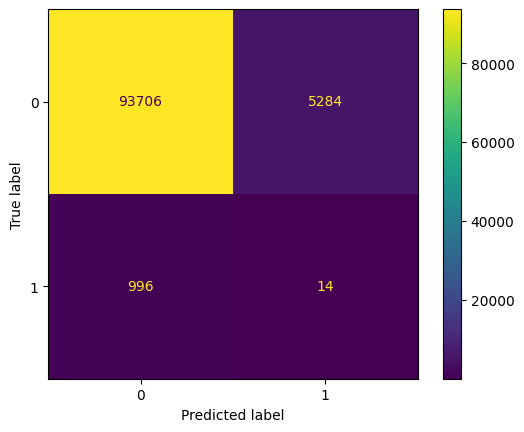

In [ ]:
# Visualization
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y,
    z_predictions
)

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(
    FIGURES_DIR / "zscore_confusion_matrix.png"
)

plt.show()

In [10]:
# Create Comparison Table

results = pd.DataFrame({

    "Model":[
        "Z-Score",
        "Robust Z-Score"
    ],

    "Precision":[
        precision_score(y,z_predictions),
        precision_score(y,robust_predictions)
    ],

    "Recall":[
        recall_score(y,z_predictions),
        recall_score(y,robust_predictions)
    ],

    "F1":[
        f1_score(y,z_predictions),
        f1_score(y,robust_predictions)
    ]
})

results

,Model,Precision,Recall,F1
0,Z-Score,0.002643,0.013861,0.004439
1,Robust Z-Score,0.007526,0.148515,0.014326


In [ ]:
results.to_csv(
    RESULTS_DIR / "baseline_results.csv",
    index=False
)

In [12]:
# Model 3

# Step 4: Isolation Forest

from sklearn.ensemble import IsolationForest

iso_model = IsolationForest(
    contamination=0.01,
    random_state=42
)

iso_model.fit(X_scaled)

,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.01
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",None
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ndom_state=42)


In [13]:
iso_predictions = iso_model.predict(X_scaled)

iso_predictions = [
    1 if x == -1 else 0
    for x in iso_predictions
]

In [14]:
# Step 5 — Evaluate Isolation Forest

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

print(
    "Accuracy:",
    accuracy_score(y, iso_predictions)
)

print(
    "Precision:",
    precision_score(y, iso_predictions)
)

print(
    "Recall:",
    recall_score(y, iso_predictions)
)

print(
    "F1:",
    f1_score(y, iso_predictions)
)

Accuracy: 0.9801
Precision: 0.01
Recall: 0.009900990099009901
F1: 0.009950248756218905


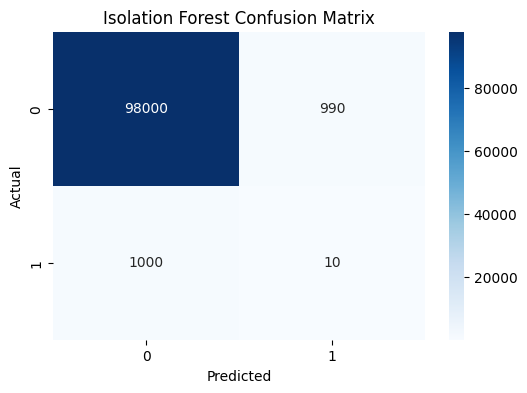

In [ ]:
# Step 6 — Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y,
    iso_predictions
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    "Isolation Forest Confusion Matrix"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(
    FIGURES_DIR / "isolation_forest_confusion_matrix.png",
    dpi=300
)

plt.show()

In [16]:
# Step 7 — Local Outlier Factor (LOF)
# Train

from sklearn.neighbors import LocalOutlierFactor

lof_model = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.01
)

lof_predictions = lof_model.fit_predict(
    X_scaled
)

In [17]:
# Convert Output

lof_predictions = [
    1 if x == -1 else 0
    for x in lof_predictions
]

In [18]:
# Step 8 — Evaluate LOF

print(
    "Accuracy:",
    accuracy_score(y, lof_predictions)
)

print(
    "Precision:",
    precision_score(y, lof_predictions)
)

print(
    "Recall:",
    recall_score(y, lof_predictions)
)

print(
    "F1:",
    f1_score(y, lof_predictions)
)

Accuracy: 0.97994
Precision: 0.002
Recall: 0.0019801980198019802
F1: 0.001990049751243781


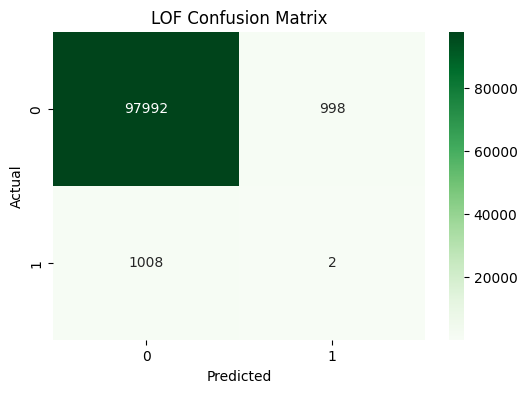

In [ ]:
# Step 9 — LOF Confusion Matrix
cm = confusion_matrix(
    y,
    lof_predictions
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title(
    "LOF Confusion Matrix"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(
    FIGURES_DIR / "lof_confusion_matrix.png",
    dpi=300
)

plt.show()

In [20]:
# Step 10 — ROC Curve

# For Isolation Forest:

from sklearn.metrics import roc_curve, auc

iso_scores = -iso_model.decision_function(
    X_scaled
)

fpr_iso, tpr_iso, _ = roc_curve(
    y,
    iso_scores
)

auc_iso = auc(
    fpr_iso,
    tpr_iso
)

In [21]:
# For LOF:

lof_scores = -lof_model.negative_outlier_factor_

fpr_lof, tpr_lof, _ = roc_curve(
    y,
    lof_scores
)

auc_lof = auc(
    fpr_lof,
    tpr_lof
)

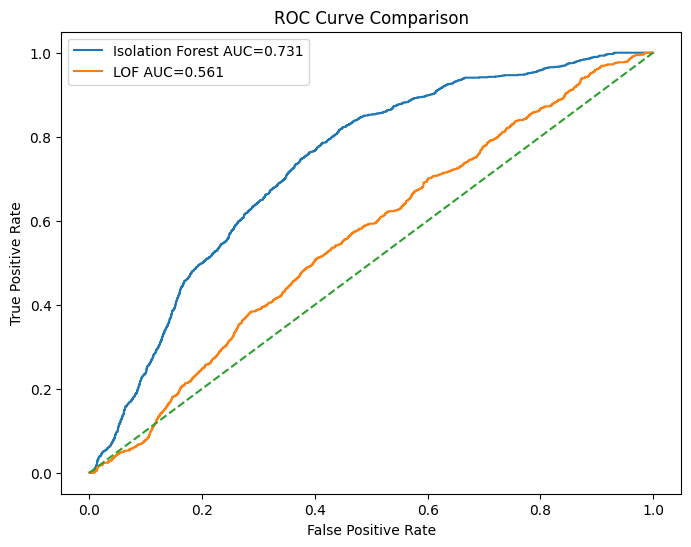

In [ ]:
# Step 11 — Plot ROC
plt.figure(figsize=(8,6))

plt.plot(
    fpr_iso,
    tpr_iso,
    label=f'Isolation Forest AUC={auc_iso:.3f}'
)

plt.plot(
    fpr_lof,
    tpr_lof,
    label=f'LOF AUC={auc_lof:.3f}'
)

plt.plot(
    [0,1],
    [0,1],
    '--'
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(
    FIGURES_DIR / "roc_curve_comparison.png",
    dpi=300
)

plt.show()

In [23]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

# Z-Score Metrics
z_precision = precision_score(y, z_predictions)
z_recall = recall_score(y, z_predictions)
z_f1 = f1_score(y, z_predictions)

# Robust Z-Score Metrics
robust_precision = precision_score(y, robust_predictions)
robust_recall = recall_score(y, robust_predictions)
robust_f1 = f1_score(y, robust_predictions)

# Isolation Forest Metrics
iso_precision = precision_score(y, iso_predictions)
iso_recall = recall_score(y, iso_predictions)
iso_f1 = f1_score(y, iso_predictions)

# LOF Metrics
lof_precision = precision_score(y, lof_predictions)
lof_recall = recall_score(y, lof_predictions)
lof_f1 = f1_score(y, lof_predictions)

In [24]:
# Step 12 — Create Model Comparison Table

comparison = pd.DataFrame({

    "Model":[
        "Z-Score",
        "Robust Z-Score",
        "Isolation Forest",
        "LOF"
    ],

    "Precision":[
        z_precision,
        robust_precision,
        precision_score(y, iso_predictions),
        precision_score(y, lof_predictions)
    ],

    "Recall":[
        z_recall,
        robust_recall,
        recall_score(y, iso_predictions),
        recall_score(y, lof_predictions)
    ],

    "F1":[
        z_f1,
        robust_f1,
        f1_score(y, iso_predictions),
        f1_score(y, lof_predictions)
    ]
})

comparison

,Model,Precision,Recall,F1
0,Z-Score,0.002643,0.013861,0.004439
1,Robust Z-Score,0.007526,0.148515,0.014326
2,Isolation Forest,0.010000,0.009901,0.009950
3,LOF,0.002000,0.001980,0.001990


In [ ]:
# Save Results
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
comparison.to_csv(
    RESULTS_DIR / "anomaly_model_comparison.csv",
    index=False
)

In [26]:
IsolationForest(
    contamination=0.02,
    random_state=42
)

,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.02
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",None
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False


In [27]:
IsolationForest(
    contamination=0.05,
    random_state=42
)

,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.05
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",None
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False


In [28]:
df["risk_level"].value_counts(normalize=True) * 100

risk_level
Medium    66.258
Low       27.342
High       6.400
Name: proportion, dtype: float64

In [29]:
class_weight='balanced'

In [30]:
# Step 1 — Load Data

import pandas as pd

df = pd.read_csv(
    "../data/processed/feature_engineered_dataset.csv"
)

In [31]:
# Step 2 — Features & Target

features = [
    'cpu_utilization',
    'memory_usage',
    'disk_io',
    'network_latency',
    'process_count',
    'thread_count',
    'context_switches',
    'cache_miss_rate',
    'temperature',
    'power_consumption',
    'uptime',
    'resource_stress_index',
    'cpu_memory_ratio',
    'disk_pressure',
    'context_switch_density',
    'cache_efficiency',
    'thermal_stress'
]

X = df[features]

y = df["risk_label"]

In [32]:
# Step 3 — Train Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [33]:
# Step 4 — Random Forest

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_feat

In [ ]:
# Step 5 — Predict

rf_predictions = rf_model.predict(
    X_test
)

In [35]:
# Step 6 — Evaluation

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

rf_precision = precision_score(
    y_test,
    rf_predictions,
    average='weighted'
)

rf_recall = recall_score(
    y_test,
    rf_predictions,
    average='weighted'
)

rf_f1 = f1_score(
    y_test,
    rf_predictions,
    average='weighted'
)

print("Accuracy:", rf_accuracy)
print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1:", rf_f1)

Accuracy: 0.98555
Precision: 0.986420135155059
Recall: 0.98555
F1: 0.985720717917979


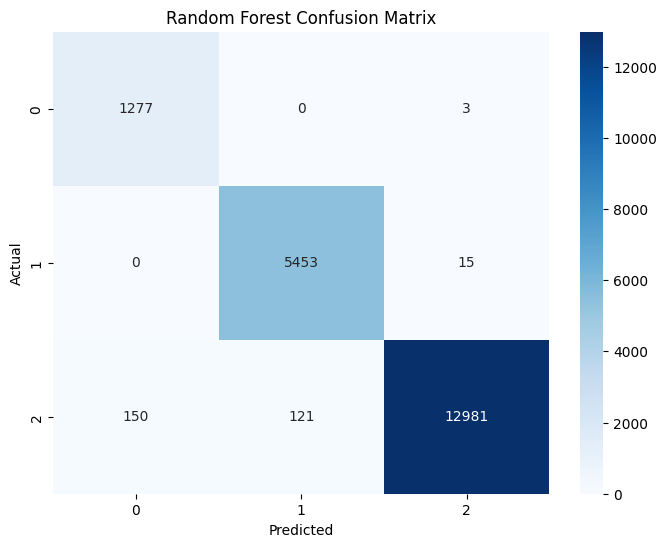

In [ ]:
# Step 7 — Random Forest Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    rf_predictions
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    "Random Forest Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(
    FIGURES_DIR / "rf_confusion_matrix.png",
    dpi=300
)

plt.show()

In [37]:
# Step 8 — Feature Importance

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

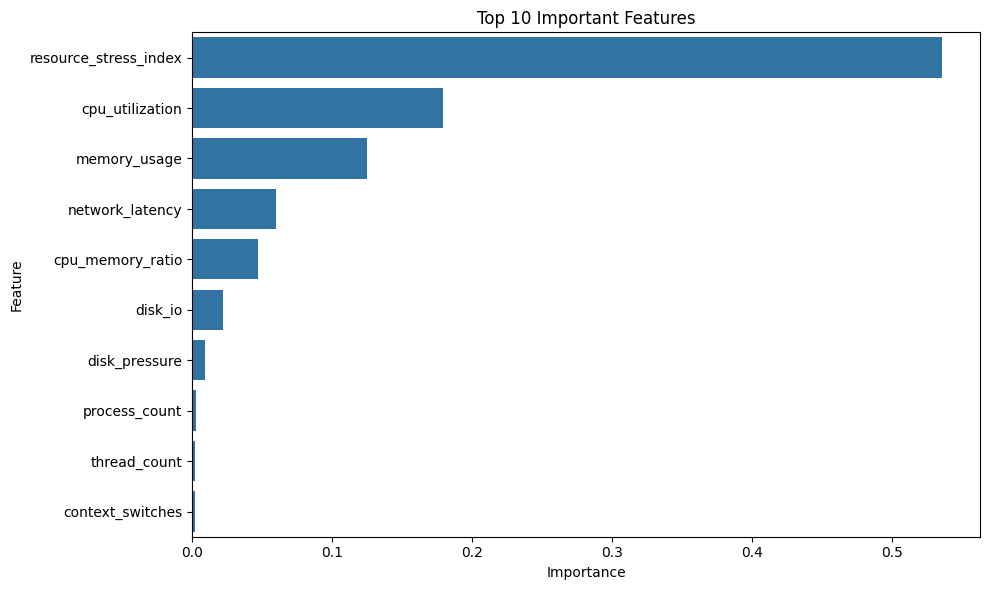

In [ ]:
# Plot:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 10 Important Features"
)

plt.tight_layout()

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(
    FIGURES_DIR / "feature_importance_rf.png",
    dpi=300
)

plt.show()

In [ ]:
# Step 9 — Save Model
import joblib

MODELS_DIR.mkdir(parents=True, exist_ok=True)
joblib.dump(
    rf_model,
    MODELS_DIR / "random_forest.pkl"
)

['../models/random_forest.pkl']

In [ ]:
# Step 10 — XGBoost
# Train:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='mlogloss'
)

xgb_model.fit(
    X_train,
    y_train
)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegress

In [41]:
# Predict:

xgb_predictions = xgb_model.predict(
    X_test
)

In [42]:
# Metrics:

xgb_accuracy = accuracy_score(
    y_test,
    xgb_predictions
)

xgb_precision = precision_score(
    y_test,
    xgb_predictions,
    average='weighted'
)

xgb_recall = recall_score(
    y_test,
    xgb_predictions,
    average='weighted'
)

xgb_f1 = f1_score(
    y_test,
    xgb_predictions,
    average='weighted'
)

In [43]:
# Step 11 — Final Comparison Table

risk_results = pd.DataFrame({

    "Model":[
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy":[
        rf_accuracy,
        xgb_accuracy
    ],

    "Precision":[
        rf_precision,
        xgb_precision
    ],

    "Recall":[
        rf_recall,
        xgb_recall
    ],

    "F1":[
        rf_f1,
        xgb_f1
    ]
})

risk_results

,Model,Accuracy,Precision,Recall,F1
0,Random Forest,0.98555,0.986420,0.98555,0.985721
1,XGBoost,0.99630,0.996307,0.99630,0.996302


In [ ]:
# Save:
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
risk_results.to_csv(
    RESULTS_DIR / "risk_prediction_results.csv",
    index=False
)

In [45]:
risk_results

,Model,Accuracy,Precision,Recall,F1
0,Random Forest,0.98555,0.986420,0.98555,0.985721
1,XGBoost,0.99630,0.996307,0.99630,0.996302


In [46]:
importance.head(10)

,Feature,Importance
11,resource_stress_index,0.536169
0,cpu_utilization,0.179426
1,memory_usage,0.124885
3,network_latency,0.059919
12,cpu_memory_ratio,0.046849
2,disk_io,0.022121
13,disk_pressure,0.009150
4,process_count,0.002635
5,thread_count,0.002328
6,context_switches,0.002268
